In [44]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(style="whitegrid", palette="Paired")
plt.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/test.csv
/kaggle/input/titanic/train.csv
/kaggle/input/titanic/gender_submission.csv


In [45]:
titanic = pd.read_csv('../input/titanic/train.csv', index_col = 'PassengerId')
titanic_test = pd.read_csv('../input/titanic/test.csv', index_col = 'PassengerId')

In [46]:
titanic

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [47]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [48]:
titanic.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [49]:
surv_count = titanic.Survived.value_counts()

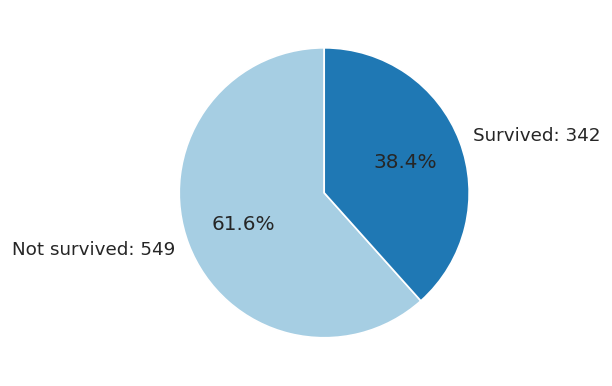

In [50]:
surv_pie = plt.pie(titanic.Survived.value_counts(), 
                   labels=[f'Not survived: {surv_count[0]}', f'Survived: {surv_count[1]}'], 
                   autopct='%1.1f%%', startangle=90)

Text(0.5, 0, '')

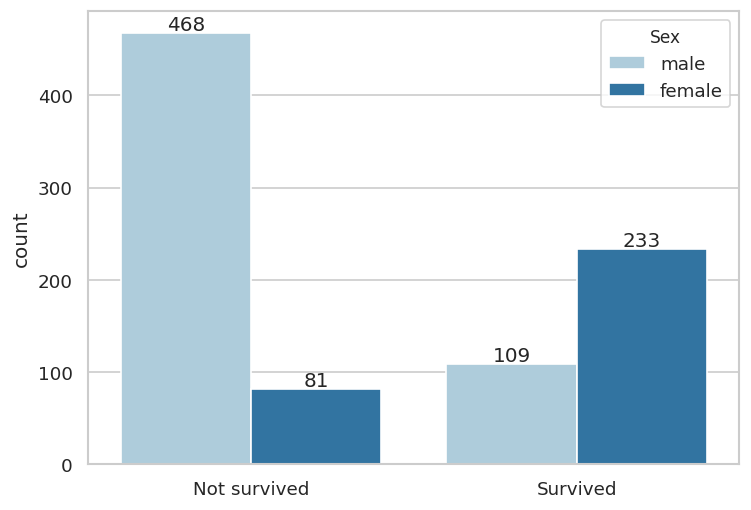

In [51]:
plt.figure(figsize=(7,5))
gender_surv = sns.countplot(x="Survived", hue="Sex", data=titanic)
gender_surv.set_xticklabels(['Not survived', 'Survived'])
for p in gender_surv.patches:
    gender_surv.annotate(p.get_height(), 
                        (p.get_x() + p.get_width() / 2.0, 
                         p.get_height()), 
                         ha = 'center', 
                         va = 'center', 
                         xytext = (0, 5),
                         textcoords = 'offset points')
plt.xlabel('')

In [52]:
pd.crosstab(titanic['Survived'],titanic['Sex'])

Sex,female,male
Survived,,
0,81,468
1,233,109


In [53]:
titanic['Age_group'] = titanic.Age

In [54]:
titanic.Age_group.fillna(-1, inplace = True)
titanic.Age_group = titanic.Age_group.map(lambda age: int(age//10+1))

In [55]:
titanic.Age_group.value_counts()

3    220
0    177
4    167
2    102
5     89
1     62
6     48
7     19
8      6
9      1
Name: Age_group, dtype: int64

In [56]:
titanic[titanic.Age >= 70]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_group
PassengerId,,,,,,,,,,,,
97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C,8
117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q,8
494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C,8
631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S,9
673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S,8
746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S,8
852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S,8


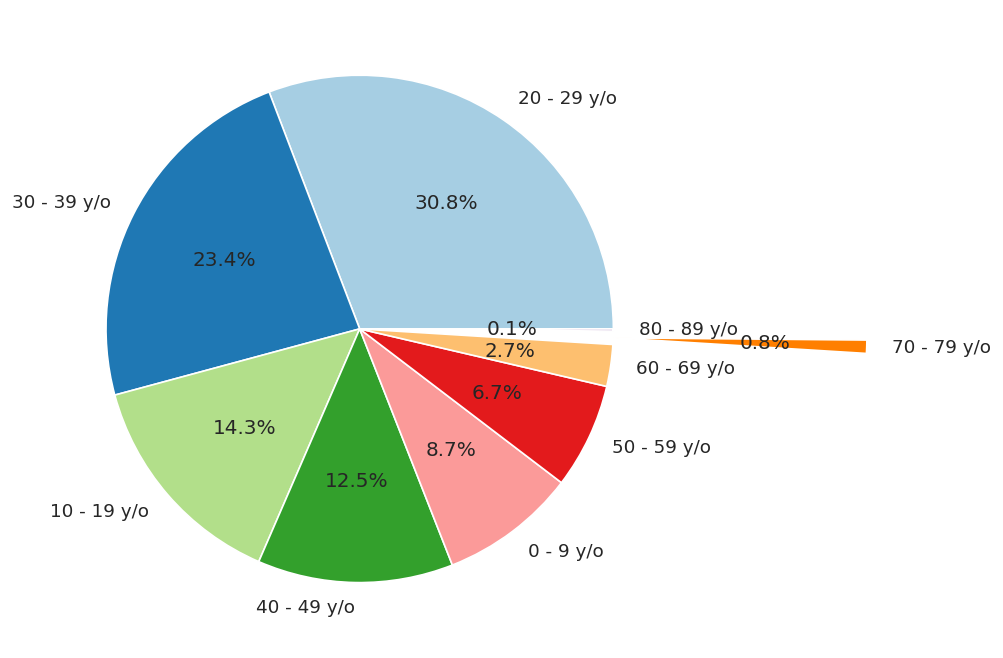

In [57]:
age_group_pie_set = titanic.Age_group[titanic.Age_group != 0].value_counts()
explode = (0,0,0,0,0,0,0,1,0)
labels_group_age = [f'{x*10-10} - {x*10-1} y/o' for x in age_group_pie_set.index]
plt.figure(figsize=(9,7))
age_group_pie = plt.pie(age_group_pie_set, explode=explode, labels=labels_group_age, autopct='%1.1f%%')

In [58]:
by_gender = pd.pivot_table(titanic, values = 'Age', index=['Survived', 'Sex'],
                     columns=['Age_group'], fill_value=0, aggfunc=len)
by_gender.drop(0, axis=1, inplace=True)
by_gender

Age_group         1   2    3   4   5   6   7  8  9
Survived Sex                                      
0        female  11  11   20  10  10   2   0  0  0
         male    13  50  123  84  45  26  13  6  0
1        female  19  34   52  50  22  16   4  0  0
         male    19   7   25  23  12   4   2  0  1

In [59]:
age_group_surv = titanic.groupby(['Age_group', 'Survived'])
age_group_surv = age_group_surv.size().unstack()
age_group_surv = age_group_surv[1:].fillna(0)
age_group_surv

Survived,0,1
Age_group,,
1,24.0,38.0
2,61.0,41.0
3,143.0,77.0
4,94.0,73.0
5,55.0,34.0
6,28.0,20.0
7,13.0,6.0
8,6.0,0.0
9,0.0,1.0


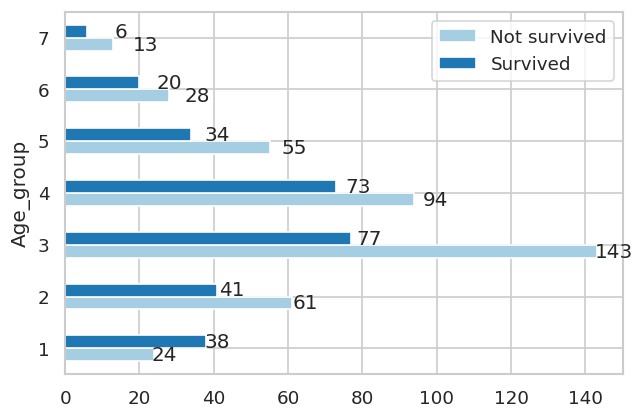

In [60]:
age_group_surv_barh = age_group_surv[:7].plot(kind='barh')
plt.legend(['Not survived', 'Survived'])
for p in age_group_surv_barh.patches:
    age_group_surv_barh.annotate(int(p.get_width()), 
                        (p.get_y() + p.get_width()+2, 
                         p.get_height() + p.get_y()-0.3),
                         ha = 'center', 
                         va = 'center',
                         xytext = (2, 5),
                         textcoords = 'offset points')

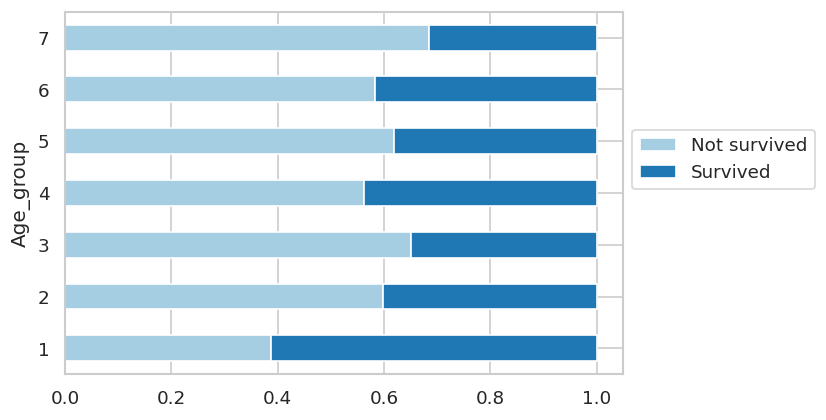

In [61]:
age_group_surv[:7].apply(lambda x:x/x.sum(), axis=1).plot(kind='barh', stacked=True, legend=False)
plt.legend(['Not survived', 'Survived'], bbox_to_anchor=(1.0, 0.7))

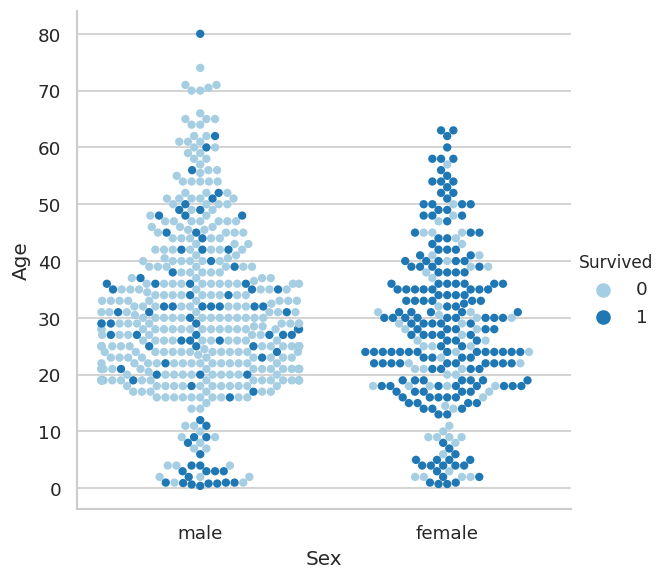

In [62]:
sns.catplot(x = 'Sex', y = 'Age', hue = 'Survived',data=titanic, kind='swarm')

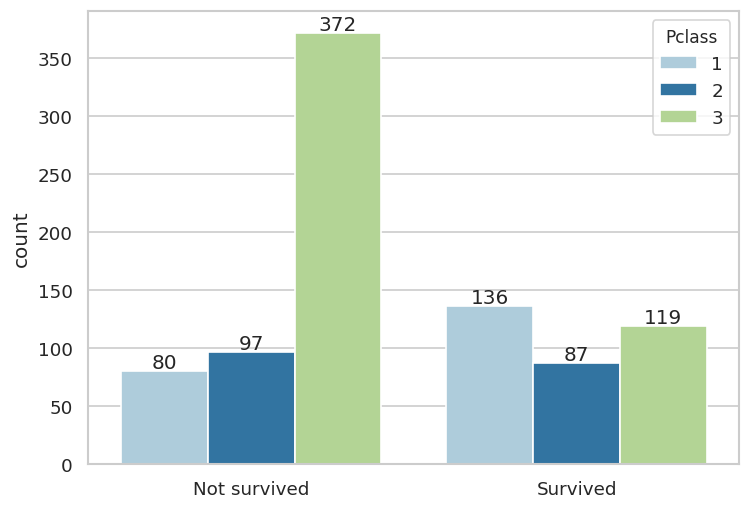

In [63]:
plt.figure(figsize=(7,5))
pcl_surv = sns.countplot(x='Survived', hue='Pclass',data=titanic)
pcl_surv.set_xticklabels(['Not survived', 'Survived'])
plt.xlabel('')
for p in pcl_surv.patches:
    pcl_surv.annotate(p.get_height(), 
                        (p.get_x() + p.get_width() / 2.0, 
                         p.get_height()), 
                         ha = 'center', 
                         va = 'center', 
                         xytext = (0, 5),
                         textcoords = 'offset points')

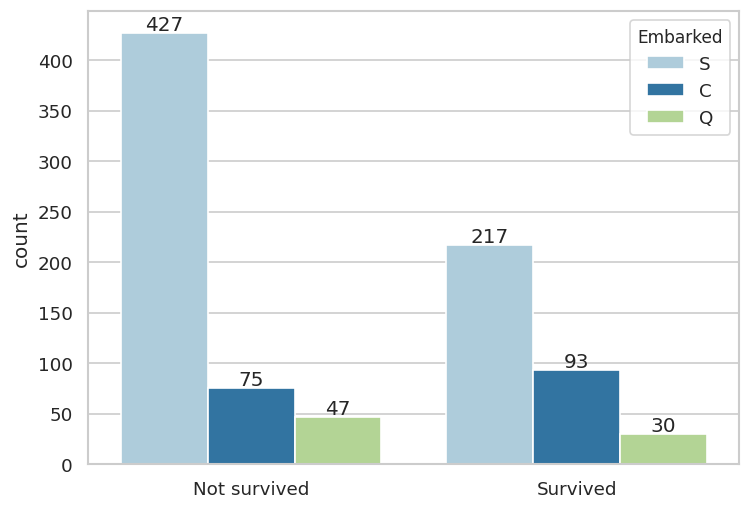

In [64]:
plt.figure(figsize=(7,5))
embarked_surv = sns.countplot(x='Survived', hue='Embarked',data=titanic)
embarked_surv.set_xticklabels(['Not survived', 'Survived'])
plt.xlabel('')
for p in embarked_surv.patches:
    embarked_surv.annotate(p.get_height(), 
                        (p.get_x() + p.get_width() / 2.0, 
                         p.get_height()), 
                         ha = 'center', 
                         va = 'center', 
                         xytext = (0, 5),
                         textcoords = 'offset points')

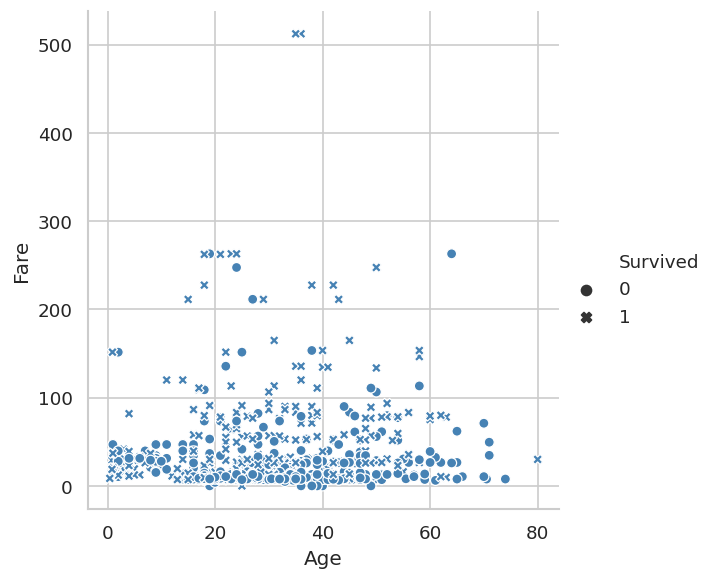

In [65]:
sns.relplot(x = 'Age', y = 'Fare', style = 'Survived', color='steelblue', data = titanic)

In [66]:
titanic[titanic.Fare == 0]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_group
PassengerId,,,,,,,,,,,,
180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S,4
264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S,5
272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S,3
278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,NaN,S,0
303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S,2
414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0,NaN,S,0
467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0,NaN,S,0
482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0,NaN,S,0
598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S,5


In [67]:
titanic.Fare[titanic.Fare == 0] = titanic.Fare.median(axis = 0)
titanic.Age[titanic.Age.isnull()] = titanic.Age.median(axis = 0)

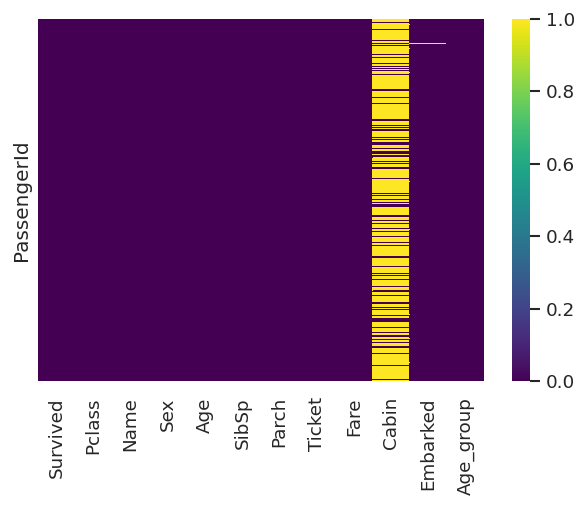

In [68]:
sns.heatmap(titanic.isnull(), yticklabels=False, cmap="viridis")

In [69]:
titanic.drop(["Cabin", "Name", "Ticket", "Age_group"], axis=1, inplace=True)
titanic.dropna(inplace=True)

In [70]:
titanic[:2]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C


In [71]:
pcl = pd.get_dummies(titanic["Pclass"],drop_first=True)
embark = pd.get_dummies(titanic["Embarked"])

In [72]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

X = titanic
a = titanic['Sex']

X['Sex'] = le.fit_transform(X['Sex'])

a = le.transform(a)
dataset = X

In [73]:
titanic = pd.concat([titanic,embark,pcl],axis=1)
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,C,Q,S,2,3
PassengerId,,,,,,,,,,,,,
1,0,3,1,22.0,1,0,7.2500,S,0,0,1,0,1
2,1,1,0,38.0,1,0,71.2833,C,1,0,0,0,0
3,1,3,0,26.0,0,0,7.9250,S,0,0,1,0,1
4,1,1,0,35.0,1,0,53.1000,S,0,0,1,0,0
5,0,3,1,35.0,0,0,8.0500,S,0,0,1,0,1


In [74]:
titanic.drop(['Pclass', 'Embarked'], axis=1, inplace = True)

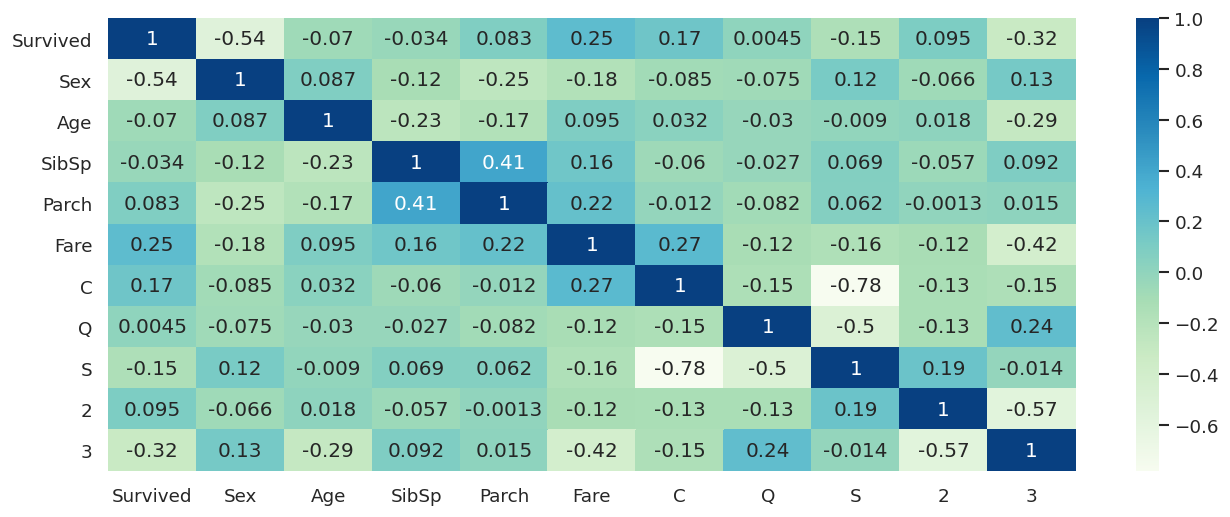

In [75]:
titanic_corr = titanic.corr()
plt.figure(figsize=(13,5))
sns.heatmap(data=titanic_corr, annot=True, cmap='GnBu')

In [76]:
X = titanic.drop("Survived", axis=1)
y = titanic["Survived"]

In [77]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X,y)

LogisticRegression()

In [78]:
titanic_test

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S


In [79]:
titanic_test.Age[titanic_test.Age.isnull()] = titanic_test.Age.median(axis = 0)
titanic_test.Fare[titanic_test.Fare == 0] = titanic_test.Fare.median(axis = 0)
titanic_test.Fare[titanic_test.Fare.isnull()] = titanic_test.Fare.median(axis = 0)

In [80]:
titanic_test.drop(["Cabin", "Name", "Ticket"], axis=1, inplace=True)

In [81]:
pcl_t = pd.get_dummies(titanic_test["Pclass"],drop_first=True)
embark_t = pd.get_dummies(titanic_test["Embarked"])

X_t = titanic_test
a_t = titanic_test['Sex']

X_t['Sex'] = le.fit_transform(X_t['Sex'])

a = le.transform(a_t)
dataset_t = X_t

In [82]:
titanic_test = pd.concat([titanic_test,embark_t,pcl_t],axis=1)
titanic_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,C,Q,S,2,3
PassengerId,,,,,,,,,,,,
892,3,1,34.5,0,0,7.8292,Q,0,1,0,0,1
893,3,0,47.0,1,0,7.0000,S,0,0,1,0,1
894,2,1,62.0,0,0,9.6875,Q,0,1,0,1,0
895,3,1,27.0,0,0,8.6625,S,0,0,1,0,1
896,3,0,22.0,1,1,12.2875,S,0,0,1,0,1


In [83]:
titanic_test.drop(['Pclass', 'Embarked'], axis=1, inplace = True)

In [84]:
predictions = log_model.predict(titanic_test)

In [85]:
submission = pd.DataFrame({
        "PassengerId": titanic_test.index,
        "Survived": predictions
    })
submission.to_csv('gender_submission.csv', index = False)